
First 5 Records of Dataset:
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None


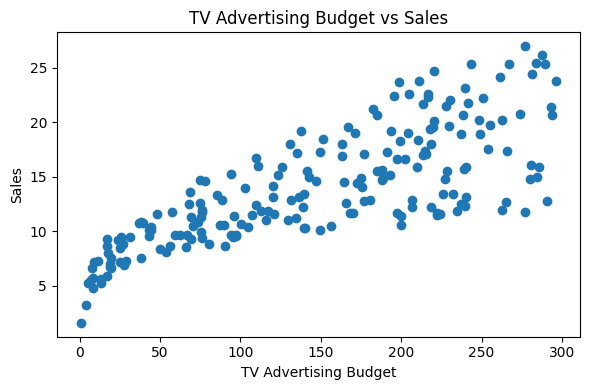


Training Data Shape: (160, 1) (160,)
Testing Data Shape: (40, 1) (40,)

Model Parameters:
Intercept (b0): 7.119638430592953
Slope (b1): 0.046529733705443346


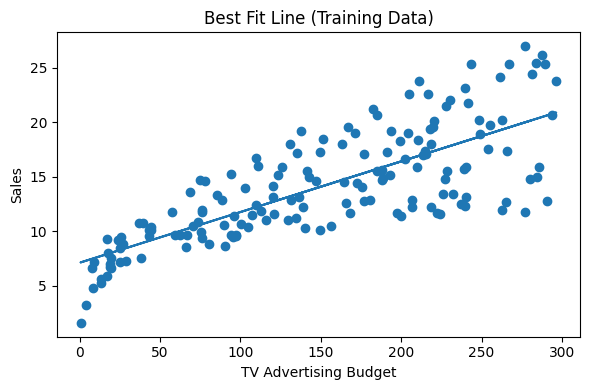


Actual vs Predicted Sales:
    Actual Sales  Predicted Sales
0           16.9        14.717944
1           22.4        16.211548
2           21.4        20.748197
3            7.3         7.664036
4           24.7        17.370139
5           12.6        10.614021
6           22.3        17.207285
7            8.4         9.446125
8           11.5        17.467851
9           14.9        15.266995
10           9.5         8.585325
11           8.7         9.734609
12          11.9        18.030861
13           5.3         7.370899
14          10.3        13.610536
15          11.7        15.038999
16           5.5         7.459305
17          16.6        16.313914
18          11.3        10.623327
19          18.9        18.165797
20          19.7        17.798212
21          12.5        10.274354
22          10.9         8.887768
23          22.2        18.793949
24           9.3        10.330190
25           8.1         9.608979
26          21.7        17.053737
27          13.4    

In [ ]:
# --------------------------------------------
# Experiment 1: Simple Linear Regression
# Sales Prediction using TV Marketing Budget
# --------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# a) Importing data and understanding its structure
df = pd.read_csv("TvMarketing.csv")

print("\nFirst 5 Records of Dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# b) Visualising Data Using Plot
plt.figure(figsize=(6, 4))
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising Budget vs Sales")
plt.tight_layout()
plt.show()

# c) Splitting Data into Training and Testing Sets (80:20)
X = df[["TV"]]     # Predictor
y = df["Sales"]    # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape, y_train.shape)
print("Testing Data Shape:", X_test.shape, y_test.shape)

# d) Train Simple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

b0 = model.intercept_
b1 = model.coef_[0]

print("\nModel Parameters:")
print("Intercept (b0):", b0)
print("Slope (b1):", b1)

# Visualizing best fit line
plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train))
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Best Fit Line (Training Data)")
plt.tight_layout()
plt.show()

# e) Display Actual vs Predicted Sales
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print("\nActual vs Predicted Sales:")
print(comparison)

# f) Computing RMSE and R² Values
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("RMSE:", rmse)
print("R² Score:", r2)



First 5 Records:
          Car       Model  Volume  Weight  CO2  Unnamed: 5
0      Toyota        Aygo    1000     790   99         NaN
1  Mitsubishi  Space Star    1200    1160   95         NaN
2       Skoda      Citigo    1000     929   95         NaN
3        Fiat         500     900     865   90         NaN
4        Mini      Cooper    1500    1140  105         NaN

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Car         36 non-null     object 
 1   Model       36 non-null     object 
 2   Volume      36 non-null     int64  
 3   Weight      36 non-null     int64  
 4   CO2         36 non-null     int64  
 5   Unnamed: 5  0 non-null      float64
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ KB
None

Correlation Matrix:
          Volume    Weight       CO2
Volume  1.000000  0.753537  0.592082
Weight  0.7535

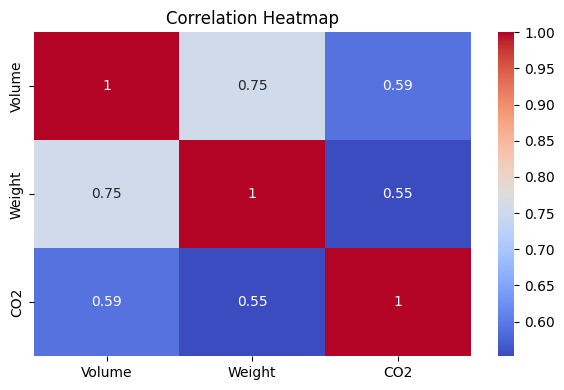

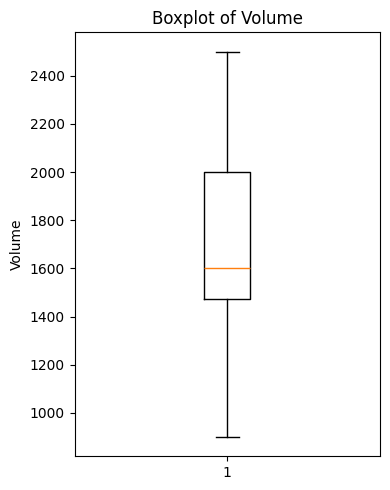

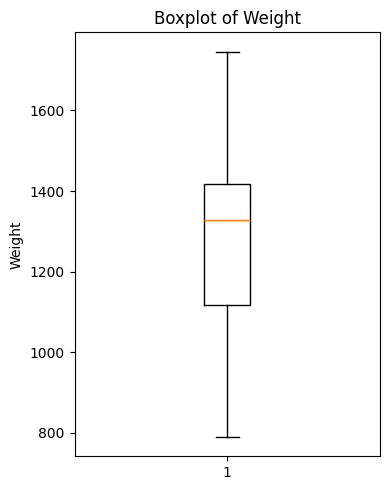

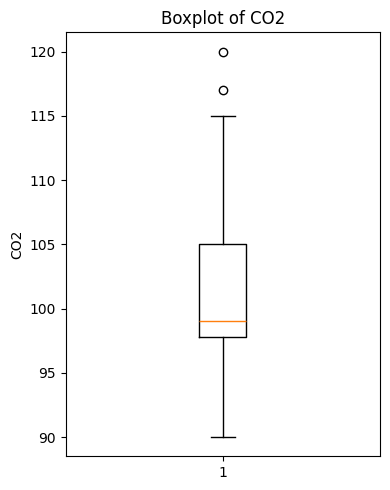

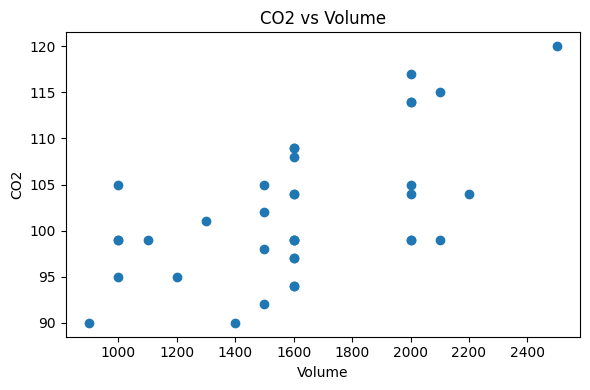

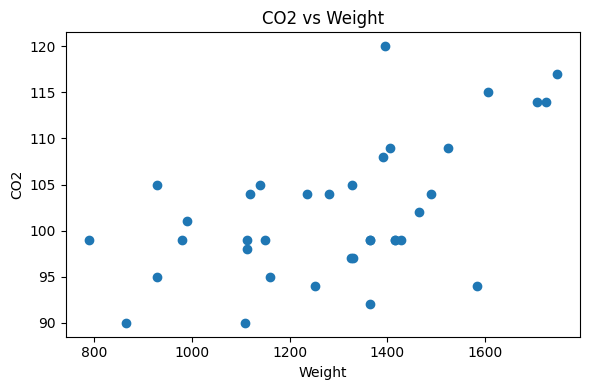


Training Data Shape: (28, 2)
Testing Data Shape: (8, 2)

Regression Model Parameters:
Intercept: 84.21502006695282
Coefficients (Volume, Weight): [0.00428741 0.00804928]


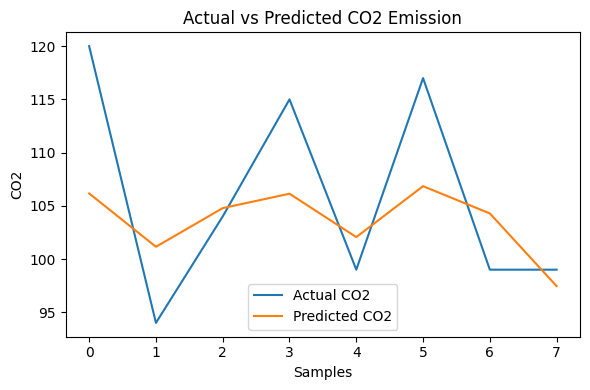


Model Evaluation Metrics:
Mean Absolute Error (MAE): 6.335639624274503
Mean Squared Error (MSE): 58.07928583657771
Root Mean Squared Error (RMSE): 7.620976698335832


In [ ]:
# ----------------------------------------------------
# Experiment 2: Multiple Linear Regression
# Dataset: DATA.csv (CO2 Emission of Cars)
# ----------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# a) Importing data and understanding its structure
df = pd.read_csv("DATA.csv")

print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# Select only numerical columns for analysis
df_num = df[["Volume", "Weight", "CO2"]]

# b) Correlation coefficient and heatmap
corr_matrix = df_num.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# c) Outlier detection using boxplots
for col in df_num.columns:
    plt.figure(figsize=(4, 5))
    plt.boxplot(df_num[col])
    plt.ylabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# d) Visualize relationship of CO2 with Volume and Weight
plt.figure(figsize=(6, 4))
plt.scatter(df_num["Volume"], df_num["CO2"])
plt.xlabel("Volume")
plt.ylabel("CO2")
plt.title("CO2 vs Volume")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df_num["Weight"], df_num["CO2"])
plt.xlabel("Weight")
plt.ylabel("CO2")
plt.title("CO2 vs Weight")
plt.tight_layout()
plt.show()

# e) Train-test split (80:20)
X = df_num[["Volume", "Weight"]]
y = df_num["CO2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# f) Train Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nRegression Model Parameters:")
print("Intercept:", model.intercept_)
print("Coefficients (Volume, Weight):", model.coef_)

# Predictions
y_pred = model.predict(X_test)

# True vs Predicted visualization
plt.figure(figsize=(6, 4))
plt.plot(y_test.values, label="Actual CO2")
plt.plot(y_pred, label="Predicted CO2")
plt.xlabel("Samples")
plt.ylabel("CO2")
plt.title("Actual vs Predicted CO2 Emission")
plt.legend()
plt.tight_layout()
plt.show()

# g) Error Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Evaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)



First 5 Records:
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  201

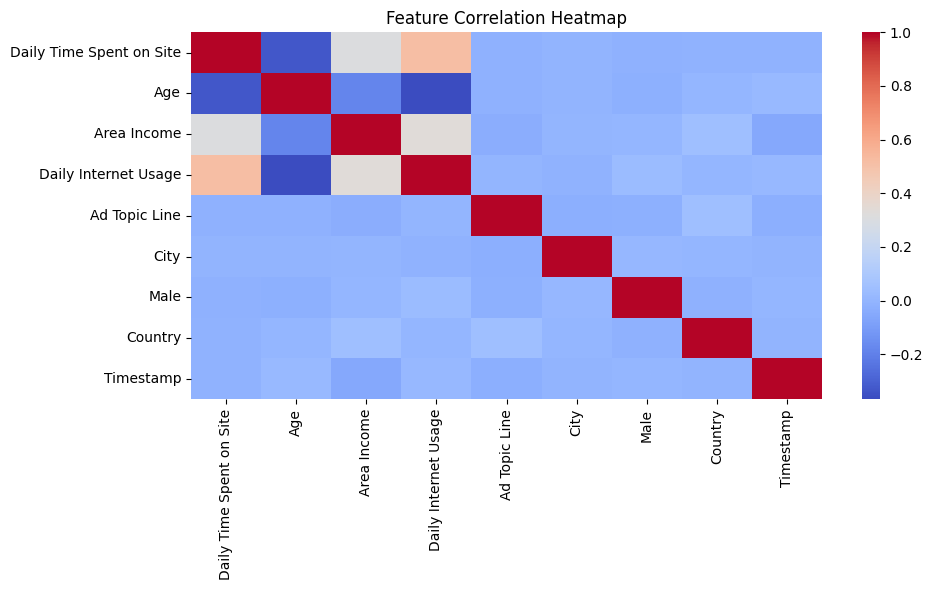


Model Parameters:
Intercept: [1.55373317]
Coefficients: [[-2.59774039  1.32177122 -1.65085983 -2.85494319  0.23641942 -0.32247184
  -0.32909244 -0.15851342  0.23296808]]

K-Fold Cross Validation Scores: [0.95  0.98  0.98  0.95  0.975]
Average CV Score: 0.967

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        89
           1       0.96      0.95      0.95       111

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



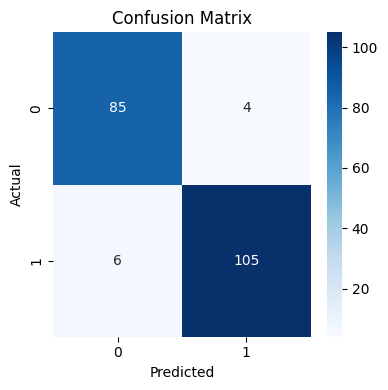

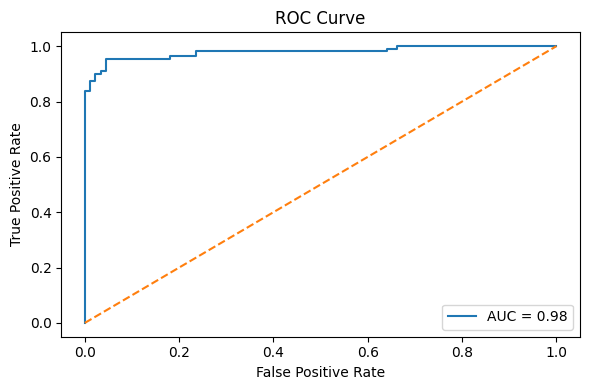

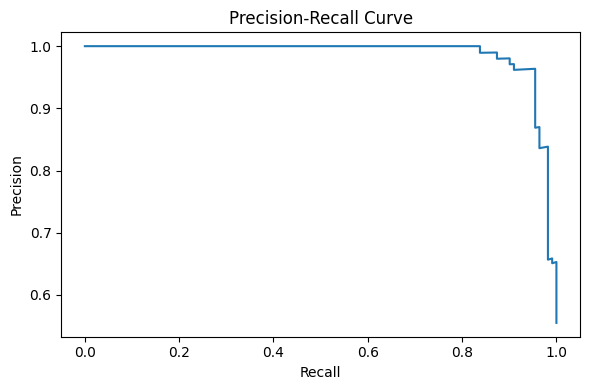

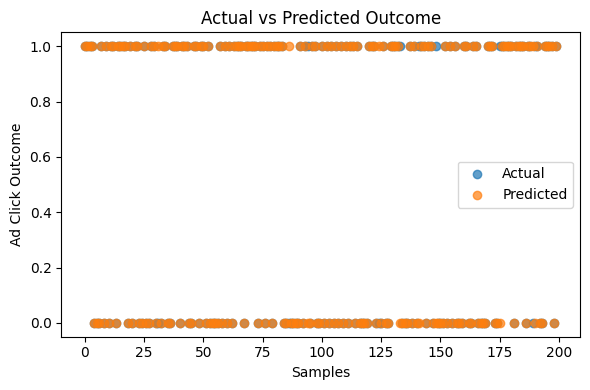

In [ ]:
# ----------------------------------------------------
# Experiment 3: Logistic Regression
# Predicting Advertisement Clicks
# ----------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

# a) Load and display dataset information
df = pd.read_csv("advertising.csv")

print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# b) Exploratory Data Analysis (EDA)

# Missing & null values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop rows with missing values (simple treatment)
df.dropna(inplace=True)

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop("Clicked on Ad", axis=1)
y = df["Clicked on Ad"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# c) Correlation matrix and heatmap
corr = pd.DataFrame(X_scaled, columns=X.columns).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# d) Train logistic regression model (80:20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("\nModel Parameters:")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# e) K-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=kfold)

print("\nK-Fold Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

# f) Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# g) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

# h) Predicted vs Actual visualization
plt.figure(figsize=(6, 4))
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)
plt.xlabel("Samples")
plt.ylabel("Ad Click Outcome")
plt.title("Actual vs Predicted Outcome")
plt.legend()
plt.tight_layout()
plt.show()


